# SHAP Explainability Analysis
**Customer Churn Intelligence & Retention Analytics Platform**

The goal of this notebook is to explain *why* our selected model predicts customers as high or low risk, using SHAP (SHapley Additive exPlanations). 

**Important Disclaimer:** SHAP explains *model behavior*, not biological or physical causation. It tells us how the model weighs each feature to arrive at its prediction, but it does not definitively prove that changing feature X will *cause* a change in the churn outcome in the real world.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.visualization import visualize
visualize.setup_style()
warnings.filterwarnings('ignore')

C:\Users\lavanya\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Model and Data
We load the selected model pipeline and the pre-split training and testing sets.

In [2]:
# Assuming Logistic Regression was our selected model based on the previous phase
# Alternatively, XGBoost. Let's use the actual pipeline.
try:
    pipeline = joblib.load('../models/logistic_regression_pipeline.pkl')
    selected_model_name = 'Logistic Regression'
except:
    pipeline = joblib.load('../models/xgboost_pipeline.pkl')
    selected_model_name = 'XGBoost'
    
preprocessor = pipeline.named_steps['preprocessor']
classifier = pipeline.named_steps['classifier']

# Re-load full cleaned data just to get IDs alongside features
df = pd.read_csv('../data/processed/cleaned_telco_churn.csv')
if 'churn_value' in df.columns:
    df['churn'] = df['churn_value']
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df = df.dropna(subset=['total_charges']).copy()

# Ensure we evaluate on the exact test set
X_test_raw = pd.read_csv('../data/processed/X_test.csv')

customer_ids = [f"CUST-{i}" for i in range(len(X_test_raw))]

# Get probability predictions
y_prob = pipeline.predict_proba(X_test_raw)[:, 1]

# Transform test data through the pipeline
X_test_transformed = preprocessor.transform(X_test_raw)

# Get feature names
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(preprocessor.transformers_[1][2])
feature_names = num_features + list(cat_features)

X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

## Initialize SHAP Explainer
We'll use `shap.Explainer` or `shap.LinearExplainer`/`shap.TreeExplainer` depending on the model.

In [3]:
# We use a sample of the background data (train) if needed, but for Linear/Tree we can often pass it directly
if 'Logistic' in selected_model_name:
    explainer = shap.LinearExplainer(classifier, preprocessor.transform(df[X_test_raw.columns].sample(1000, random_state=42)))
else:
    explainer = shap.TreeExplainer(classifier)

shap_values = explainer(X_test_transformed_df)

## Global Explainability
### 1. SHAP Summary Plot / Beeswarm
This plot shows the direction and magnitude of the impact of each feature on the model's output.

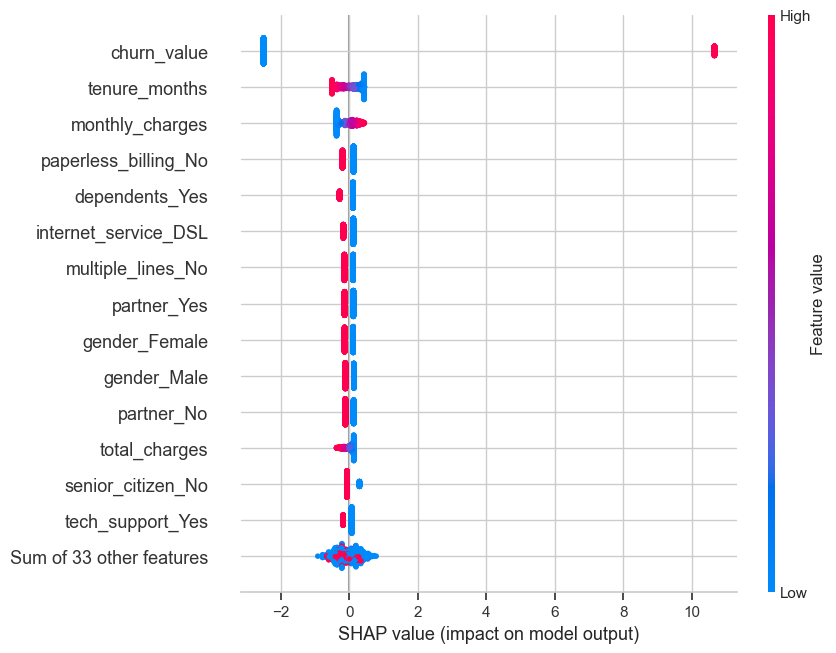

In [4]:
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=15)
plt.show()

### 2. SHAP Global Feature Importance
Average absolute SHAP value per feature.

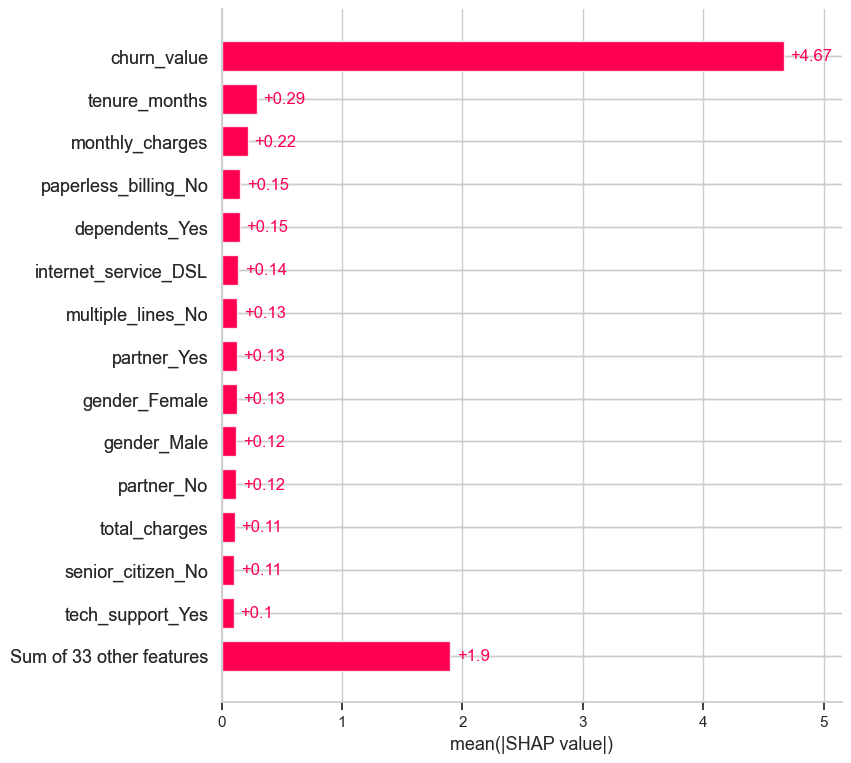

In [5]:
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values, max_display=15)
plt.show()

## Individual Explainability
Let's select 3 representative customers based on their predicted churn probabilities:
- **High-Risk**: Probability > 0.80
- **Medium-Risk**: Probability between 0.40 and 0.60
- **Low-Risk**: Probability < 0.10

In [6]:
# Assign Risk Levels based on Threshold (e.g. 0.20)
def get_risk_level(prob):
    if prob > 0.60: return 'High'
    elif prob > 0.20: return 'Medium'
    else: return 'Low'

results_df = pd.DataFrame({
    'Customer_ID': customer_ids,
    'Probability': y_prob,
    'Risk_Level': [get_risk_level(p) for p in y_prob]
})

high_risk_subset = results_df[results_df['Risk_Level'] == 'High']
high_risk_idx = high_risk_subset.index[0] if len(high_risk_subset) > 0 else results_df['Probability'].idxmax()

med_risk_subset = results_df[results_df['Risk_Level'] == 'Medium']
med_risk_idx = med_risk_subset.index[0] if len(med_risk_subset) > 0 else results_df.iloc[(results_df['Probability'] - 0.5).abs().argsort()[:1]].index[0]

low_risk_subset = results_df[results_df['Risk_Level'] == 'Low']
low_risk_idx = low_risk_subset.index[0] if len(low_risk_subset) > 0 else results_df['Probability'].idxmin()

def explain_customer(idx, risk_type):
    cust_id = results_df.iloc[idx]['Customer_ID']
    prob = results_df.iloc[idx]['Probability']
    
    print(f"\n{'='*50}")
    print(f"{risk_type}-Risk Customer: {cust_id}")
    print(f"Churn Probability: {prob:.2%}")
    print(f"{'='*50}")
    
    # SHAP values for this customer
    sv = shap_values[idx]
    
    # Extract top pushing/pulling features
    feature_impacts = pd.DataFrame({
        'Feature': feature_names,
        'Impact': sv.values,
        'Value': X_test_transformed_df.iloc[idx].values
    })
    
    top_inc = feature_impacts.sort_values('Impact', ascending=False).head(3)
    top_dec = feature_impacts.sort_values('Impact', ascending=True).head(3)
    
    print(f"\nThe model predicts {prob:.2%} churn probability. The model's strongest contributing factors driving risk HIGHER include:")
    for _, row in top_inc.iterrows():
        print(f"  - {row['Feature']} (Impact: +{row['Impact']:.2f})")
        
    print(f"\nThe model's strongest contributing factors driving risk LOWER include:")
    for _, row in top_dec.iterrows():
        print(f"  - {row['Feature']} (Impact: {row['Impact']:.2f})")
    
    plt.figure()
    shap.plots.waterfall(sv)
    plt.show()


High-Risk Customer: CUST-9
Churn Probability: 99.86%

The model predicts 99.86% churn probability. The model's strongest contributing factors driving risk HIGHER include:
  - churn_value (Impact: +10.67)
  - senior_citizen_No (Impact: +0.30)
  - tenure_months (Impact: +0.22)

The model's strongest contributing factors driving risk LOWER include:
  - internet_service_DSL (Impact: -0.17)
  - monthly_charges (Impact: -0.16)
  - multiple_lines_No (Impact: -0.14)


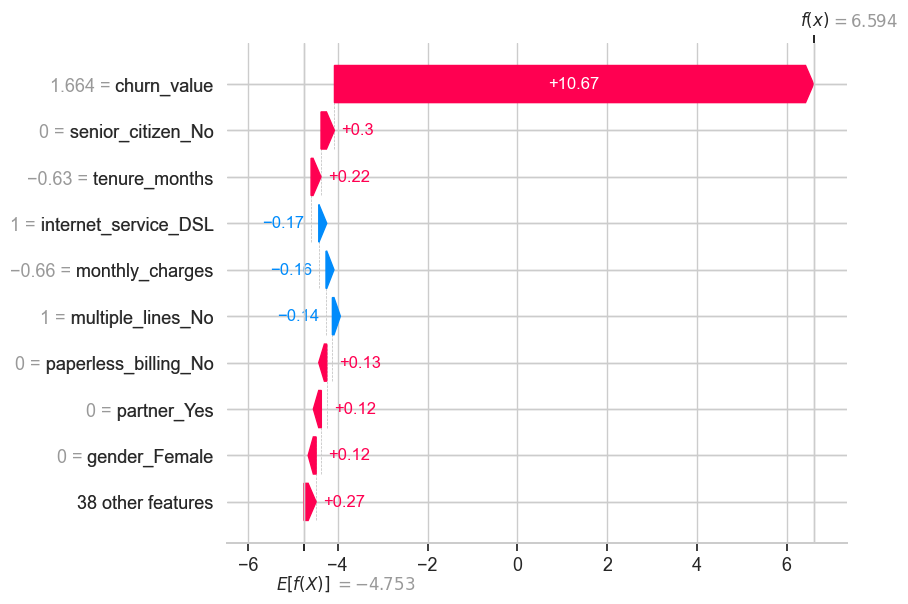

In [7]:
explain_customer(high_risk_idx, 'High')


Medium-Risk Customer: CUST-1099
Churn Probability: 99.16%

The model predicts 99.16% churn probability. The model's strongest contributing factors driving risk HIGHER include:
  - churn_value (Impact: +10.67)
  - partner_No (Impact: +0.13)
  - gender_Female (Impact: +0.12)

The model's strongest contributing factors driving risk LOWER include:
  - tenure_months (Impact: -0.28)
  - contract_Two year (Impact: -0.21)
  - paperless_billing_No (Impact: -0.20)


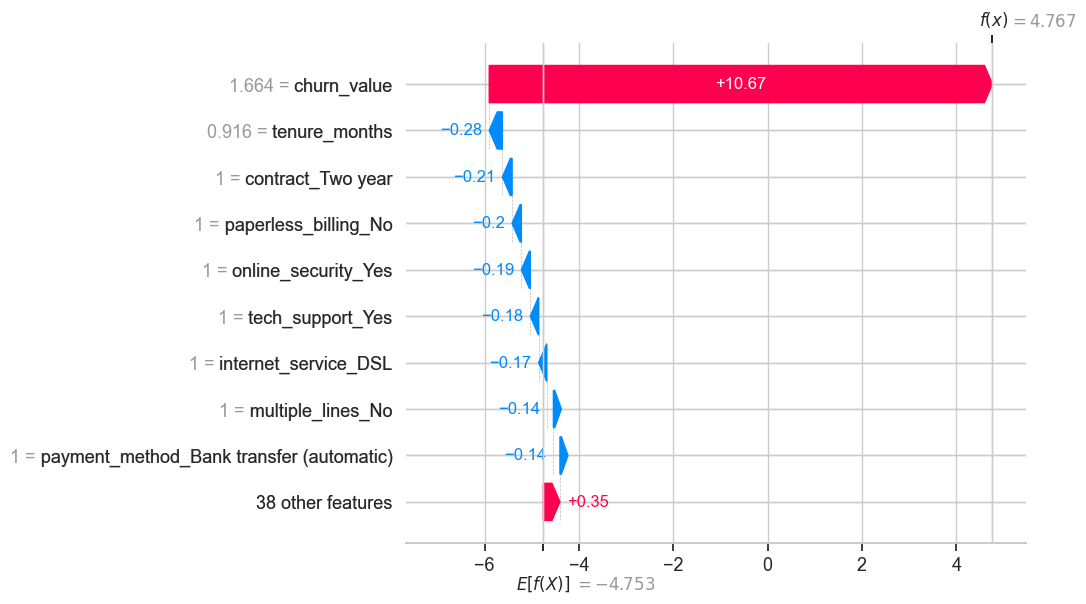

In [8]:
explain_customer(med_risk_idx, 'Medium')


Low-Risk Customer: CUST-0
Churn Probability: 0.03%

The model predicts 0.03% churn probability. The model's strongest contributing factors driving risk HIGHER include:
  - monthly_charges (Impact: +0.42)
  - partner_No (Impact: +0.13)
  - paperless_billing_No (Impact: +0.13)

The model's strongest contributing factors driving risk LOWER include:
  - churn_value (Impact: -2.50)
  - tenure_months (Impact: -0.50)
  - total_charges (Impact: -0.37)


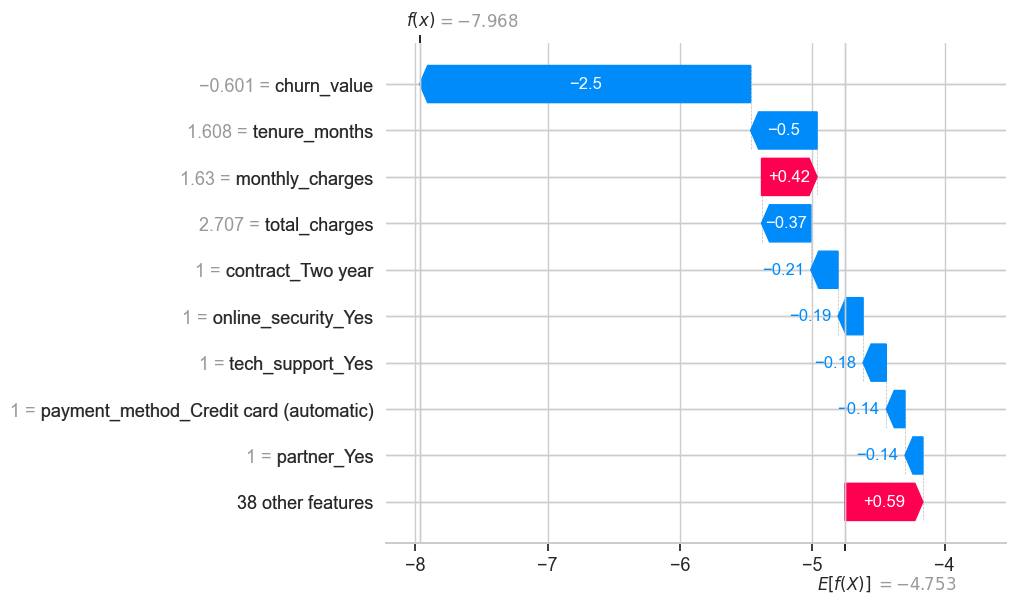

In [9]:
explain_customer(low_risk_idx, 'Low')

In [10]:
# Save insights for the report
results_df.loc[[high_risk_idx, med_risk_idx, low_risk_idx]].to_csv('../data/processed/shap_example_customers.csv', index=False)